In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
model = ChatAnthropic(model="claude-haiku-4-5-20251001")

In [4]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [11]:
def create_outline(state: BlogState) -> BlogState:
    title = state.get('title')

    prompt = f"Generate a short outline for a blog on the topic: {title}"

    outline = model.invoke(prompt).content

    state['outline'] = outline

    return state

def create_blog(state: BlogState) -> BlogState:
    title = state.get('title')
    outline = state.get('outline')

    prompt = f"Write a blog post titled '{title}', based on the following outline:\n\n{outline}"

    content = model.invoke(prompt).content

    state['content'] = content

    return state

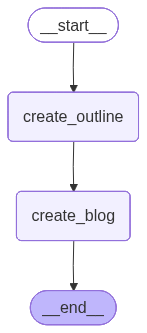

In [12]:
graph = StateGraph(BlogState)

graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

workflow

In [13]:
initial_state = {"title": "The history of ancient india"}

result = workflow.invoke(initial_state)

In [14]:
print(result.get("outline"))

# The History of Ancient India - Blog Outline

## I. Introduction
- Definition of "ancient India" and time period
- Significance in world history
- Overview of major civilizations

## II. Indus Valley Civilization (2300-1300 BCE)
- Urban planning and architecture
- Undeciphered script and seals
- Trade networks
- Decline and theories

## III. Vedic Period (1500-500 BCE)
- Arrival of Aryans
- The Vedas and their importance
- Caste system origins
- Social and economic structures

## IV. Mahajanapadas & Rise of Empires (600-322 BCE)
- Emergence of 16 kingdoms
- Rise of Magadha
- Early religious movements (Buddhism, Jainism)

## V. The Mauryan Empire (322-185 BCE)
- Chandragupta Maurya and expansion
- Emperor Ashoka's reign and conversion
- Administrative achievements
- Decline of the empire

## VI. Post-Mauryan Era (185 BCE-320 CE)
- Indo-Greeks and Kushans
- Religious and cultural developments
- Trade flourishing

## VII. The Gupta Empire (320-550 CE)
- Golden age of India
- Art, literat

In [15]:
print(result.get("content"))

# The History of Ancient India

Ancient India stands as one of the world's greatest civilizations, a land where philosophy, mathematics, art, and spirituality flourished. The subcontinent's story spans thousands of years, marked by the rise and fall of magnificent empires and the development of ideas that continue to shape our world today. Let's embark on a journey through time to explore the wonders of ancient India.

## What is Ancient India?

When historians refer to "ancient India," they typically mean the period spanning from around 2300 BCE to 550 CE. This era encompasses the emergence of the world's earliest urban civilizations through the decline of the Gupta Empire. The term "ancient India" refers not just to a specific country, but to the Indian subcontinent—a vast geographical region that includes modern-day India, Pakistan, Bangladesh, and parts of Nepal and Afghanistan.

The significance of ancient India in world history cannot be overstated. It birthed major world religio